Data Preparation Stage

In [30]:
import pandas as pd
from sklearn import *


Import data and sort by time

In [31]:
df = pd.read_csv("../../Data/CSV/silver_prices_10years.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,Close,High,Low,Open,Volume
0,2016-01-19,14.110,14.110,14.065,14.065,3
1,2016-01-20,14.147,14.147,14.147,14.147,1
2,2016-01-21,14.083,14.083,14.083,14.083,2
3,2016-01-22,14.043,14.290,14.043,14.290,7
4,2016-01-25,14.240,14.240,14.095,14.095,8


Drop an blank data

In [32]:
df = df.dropna()

Feature: Previous Day Price 7AVG 30AVG

In [33]:
#Previous Day Price
df['Prev_Close'] = df['Close'].shift(1)

# 7-Day Moving Average
df['MA7'] = df['Close'].rolling(window=7).mean()

# 30-Day Moving Average
df['MA30'] = df['Close'].rolling(window=30).mean()

# for  more acc
# momantum
df['Return'] = df['Close'].pct_change()
##short term mm
df['MA3'] = df['Close'].rolling(3).mean()
#volaitixxx
df['Volatility'] = df['Close'].rolling(7).std()

## Drop NA
df = df.dropna()

## Display
print(df[['Prev_Close', 'MA7', 'MA30']].head())

    Prev_Close        MA7       MA30
29      14.896  15.027000  14.845767
30      14.733  15.001857  14.875533
31      15.003  14.987000  14.908333
32      15.131  15.042571  14.961600
33      15.681  15.108000  15.014267


train & test 

In [34]:
# Features
X = df[['Prev_Close', 'MA7', 'MA30']]

# Target (Up/Down)
df['Tomorrow_Close'] = df['Close'].shift(-1)
df['Target'] = (df['Tomorrow_Close'] > df['Close']).astype(int)

df = df.dropna()

X = df[['Prev_Close', 'MA7', 'MA30']]
y = df['Target']


train test split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False   # VERY IMPORTANT for time series
)


Min/Max Scaling

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Use RandomForest

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(
    n_estimators=300,          # more trees = more stable
    max_depth=8,               # prevent overfitting
    min_samples_split=10,      # reduce noise learning
    min_samples_leaf=5,
    class_weight='balanced',   # VERY IMPORTANT
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
from sklearn.metrics import balanced_accuracy_score

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred))


Accuracy: 0.5472837022132797
              precision    recall  f1-score   support

           0       0.18      0.02      0.03       211
           1       0.56      0.94      0.70       286

    accuracy                           0.55       497
   macro avg       0.37      0.48      0.37       497
weighted avg       0.40      0.55      0.42       497

Balanced Accuracy: 0.4780101415172505


Display

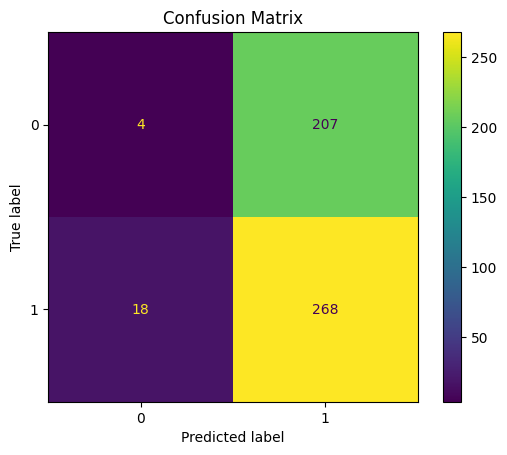

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()


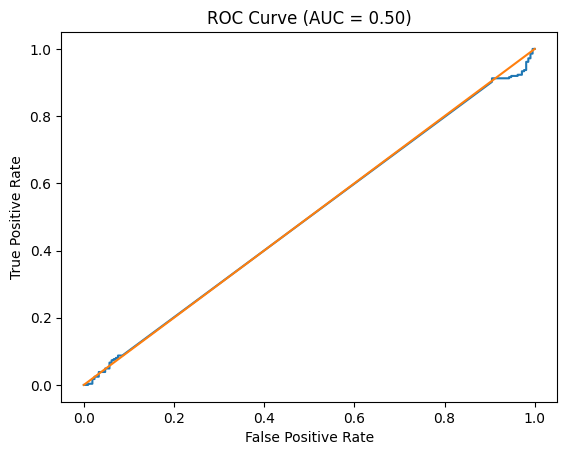

In [39]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()


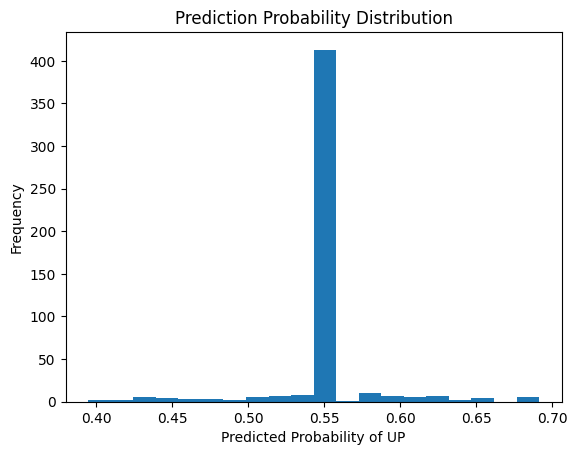

In [40]:
plt.hist(y_prob, bins=20)
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability of UP")
plt.ylabel("Frequency")
plt.show()


In [41]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

print(feature_importance.sort_values(ascending=False))

Prev_Close    0.338818
MA30          0.338682
MA7           0.322500
dtype: float64


สร้าง Upper / Lower Band (Bollinger Bands)

In [42]:
import numpy as np

# Moving Average 20 วัน
df['MA20'] = df['Close'].rolling(20).mean()

# Standard deviation 20 วัน
df['STD20'] = df['Close'].rolling(20).std()

# Upper / Lower band
df['Upper'] = df['MA20'] + 2 * df['STD20']
df['Lower'] = df['MA20'] - 2 * df['STD20']


In [ ]:
# True Range
df['H-L'] = df['High'] - df['Low']
df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))

df['TR'] = df[['H-L','H-PC','L-PC']].max(axis=1)

# ATR 14 วัน
df['ATR'] = df['TR'].rolling(14).mean()

# Stop price (Long position)
df['Stop'] = df['Close'] - 2 * df['ATR']



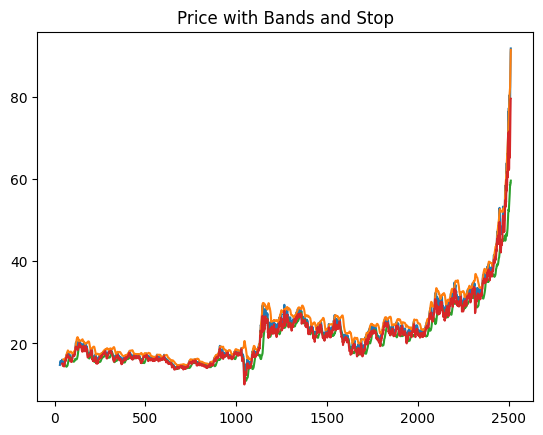

In [44]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df['Close'])
plt.plot(df['Upper'])
plt.plot(df['Lower'])
plt.plot(df['Stop'])

plt.title("Price with Bands and Stop")
plt.show()


ddd

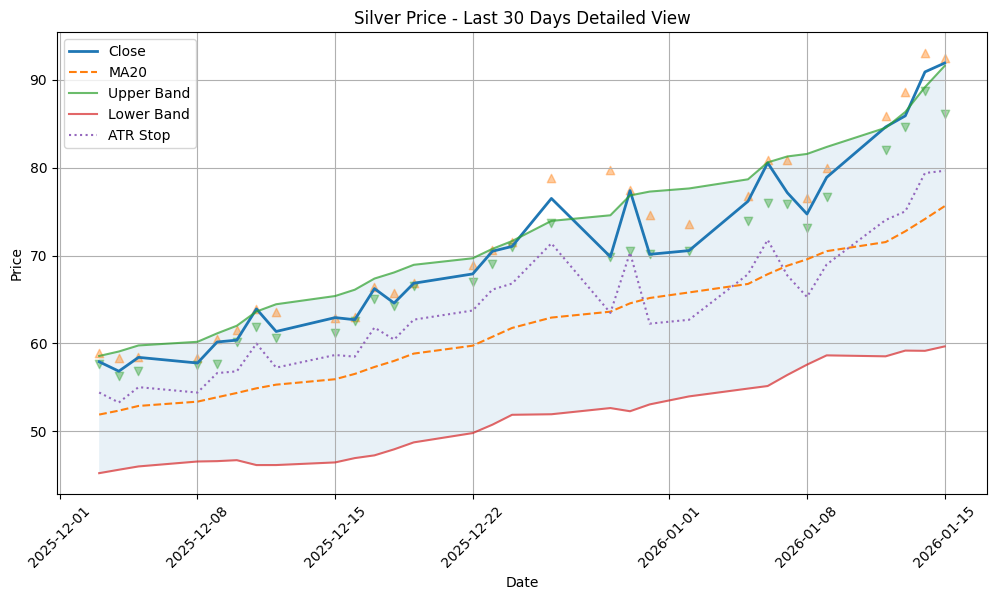

In [46]:
import matplotlib.pyplot as plt

# เลือก 30 วันล่าสุด
df_30 = df.tail(30)

plt.figure(figsize=(12,6))

# ราคา
plt.plot(df_30['Date'], df_30['Close'], label='Close', linewidth=2)

# Moving Average
plt.plot(df_30['Date'], df_30['MA20'], label='MA20', linestyle='--')

# Upper / Lower Bands
plt.plot(df_30['Date'], df_30['Upper'], label='Upper Band', alpha=0.7)
plt.plot(df_30['Date'], df_30['Lower'], label='Lower Band', alpha=0.7)

plt.fill_between(df_30['Date'],
                 df_30['Upper'],
                 df_30['Lower'],
                 alpha=0.1)

# Stop price
plt.plot(df_30['Date'], df_30['Stop'], label='ATR Stop', linestyle=':')

# High / Low จุดสูงสุดต่ำสุด
plt.scatter(df_30['Date'], df_30['High'], marker='^', alpha=0.4)
plt.scatter(df_30['Date'], df_30['Low'], marker='v', alpha=0.4)

plt.title("Silver Price - Last 30 Days Detailed View")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()
